In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.mixed_precision import set_global_policy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import datetime
import os


# 2. CIFAR-10 Veri Setini Yükleme (Kaggle'da yerleşik)
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Sınıf etiketleri
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Veri seti boyutlarını kontrol etme
print("Eğitim veri seti boyutu:", X_train.shape)
print("Test veri seti boyutu:", X_test.shape)
print("Eğitim etiket boyutu:", y_train.shape)
print("Test etiket boyutu:", y_test.shape)

2025-05-03 08:10:19.760334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746259819.958259      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746259820.015542      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Eğitim veri seti boyutu: (50000, 32, 32, 3)
Test veri seti boyutu: (10000, 32, 32, 3)
Eğitim etiket boyutu: (50000, 1)
Test etiket boyutu: (10000, 1)


In [3]:
# 2. CIFAR-10 Veri Setini Yükleme (Kaggle'da yerleşik)
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Sınıf etiketleri
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Veri seti boyutlarını kontrol etme
print("Eğitim veri seti boyutu:", X_train.shape)
print("Test veri seti boyutu:", X_test.shape)
print("Eğitim etiket boyutu:", y_train.shape)
print("Test etiket boyutu:", y_test.shape)

Eğitim veri seti boyutu: (50000, 32, 32, 3)
Test veri seti boyutu: (10000, 32, 32, 3)
Eğitim etiket boyutu: (50000, 1)
Test etiket boyutu: (10000, 1)


In [4]:
# 3. Veri Ön İşleme
# Piksel değerlerini 0-1 aralığına normalize etme
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Veri artırma
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)
datagen.fit(X_train)

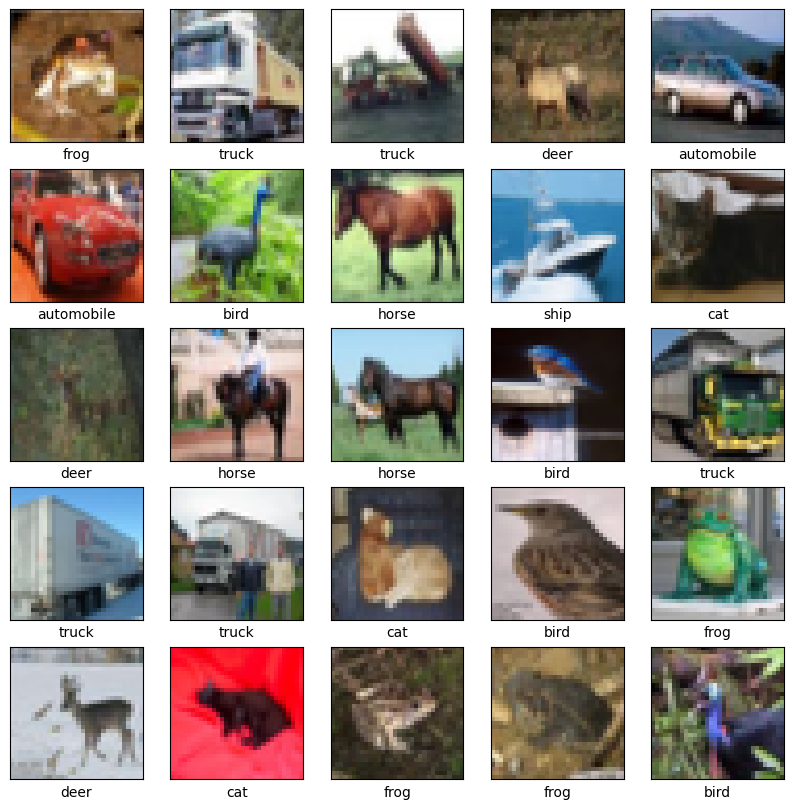

In [5]:
# 4. Veri Görselleştirme
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

In [6]:
# 5. CNN Modelini Oluşturma (Hiperparametre Optimizasyonu)
model = models.Sequential([
    # 1. Evrişim Bloğu
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # 2. Evrişim Bloğu
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # 3. Evrişim Bloğu
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # 4. Evrişim Bloğu
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Düzleştirme ve Yoğun Katmanlar
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax', dtype='float32')  # Mixed precision için çıktı katmanı
])

# Model özeti
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1746259841.057727      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 7,327,306 (27.95 MB)

 Trainable params: 7,320,394 (27.93 MB)

 Non-trainable params: 6,912 (27.00 KB)

In [7]:
# 6. Öğrenme Oranı Planlayıcısı
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [8]:
# 7. Modeli Derleme
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
# 8. Modeli Eğitme
start_time = datetime.datetime.now()
history = model.fit(datagen.flow(X_train, y_train, batch_size=128),
                    epochs=100,
                    validation_data=(X_test, y_test),
                    callbacks=[
                        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
                        lr_schedule
                    ])
end_time = datetime.datetime.now()
print("Eğitim süresi:", end_time - start_time)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746259852.595457      94 service.cc:148] XLA service 0x7ef97800e290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746259852.596181      94 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746259853.529822      94 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.1382 - loss: 3.4957 

I0000 00:00:1746259863.009449      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 94ms/step - accuracy: 0.2463 - loss: 2.5040 - val_accuracy: 0.1696 - val_loss: 2.8710 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.4436 - loss: 1.5622 - val_accuracy: 0.5478 - val_loss: 1.2720 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.5536 - loss: 1.2741 - val_accuracy: 0.6075 - val_loss: 1.1404 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.6230 - loss: 1.0873 - val_accuracy: 0.5886 - val_loss: 1.4071 - learning_rate: 0.0010
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.6706 - loss: 0.9528 - val_accuracy: 0.7234 - val_loss: 0.8072 - learning_rate: 0.0010
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.7030 - loss: 0.8717 - val_accuracy: 0.7091 - val_loss: 0.8677 - learning_rate: 0.0010
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.7208 - loss: 

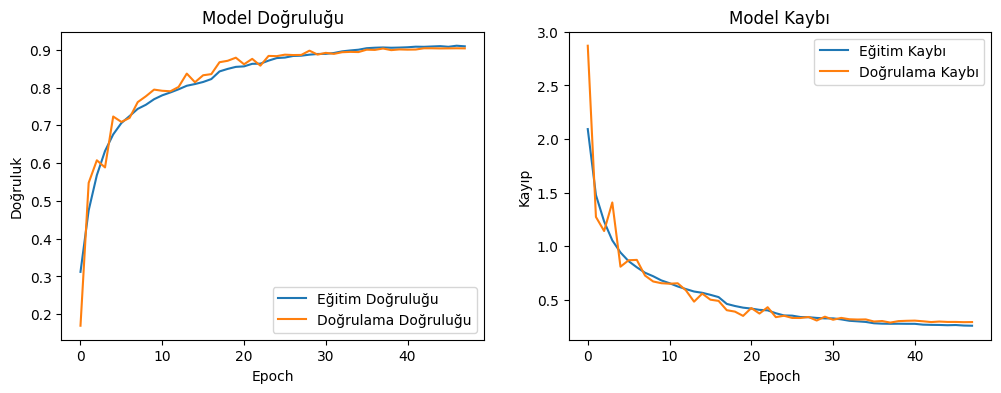

In [10]:
# 9. Eğitim Sonuçlarını Görselleştirme
# Doğruluk grafiği
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.savefig('/kaggle/working/training_plots.png')
plt.show()

In [11]:
# 10. Model Değerlendirme
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest doğruluğu: {test_acc:.4f}")
print(f"Test kaybı: {test_loss:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.9034 - loss: 0.2852

Test doğruluğu: 0.9034
Test kaybı: 0.2852


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


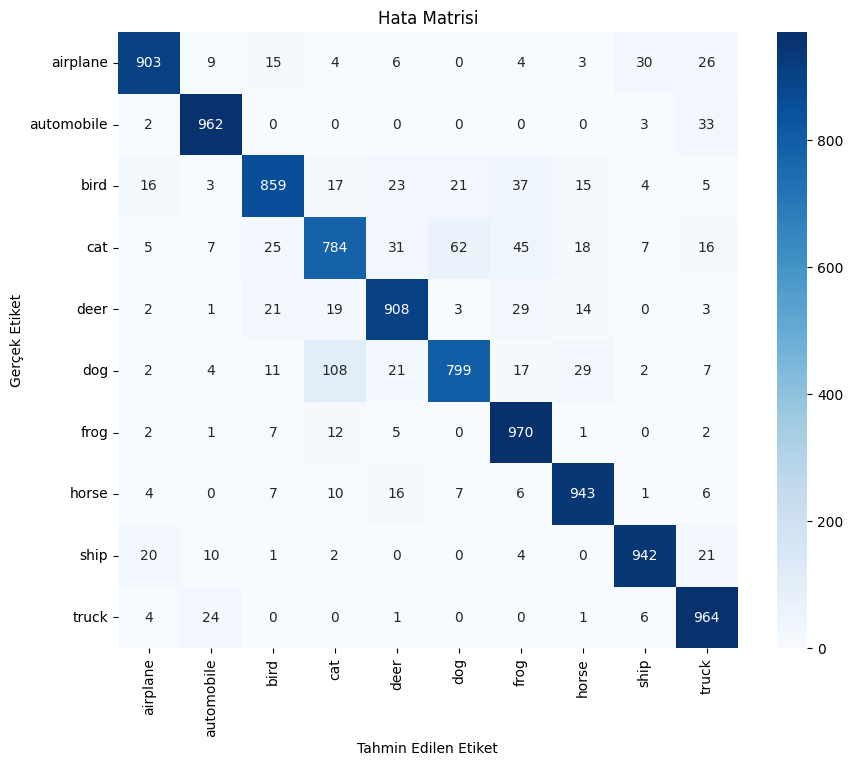


Sınıflandırma Raporu:
              precision    recall  f1-score   support

    airplane       0.94      0.90      0.92      1000
  automobile       0.94      0.96      0.95      1000
        bird       0.91      0.86      0.88      1000
         cat       0.82      0.78      0.80      1000
        deer       0.90      0.91      0.90      1000
         dog       0.90      0.80      0.84      1000
        frog       0.87      0.97      0.92      1000
       horse       0.92      0.94      0.93      1000
        ship       0.95      0.94      0.94      1000
       truck       0.89      0.96      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [12]:
# 11. Tahminler ve Hata Matrisi
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = y_test.flatten()

# Hata matrisi
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Hata Matrisi')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen Etiket')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

# Sınıflandırma raporu
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names))

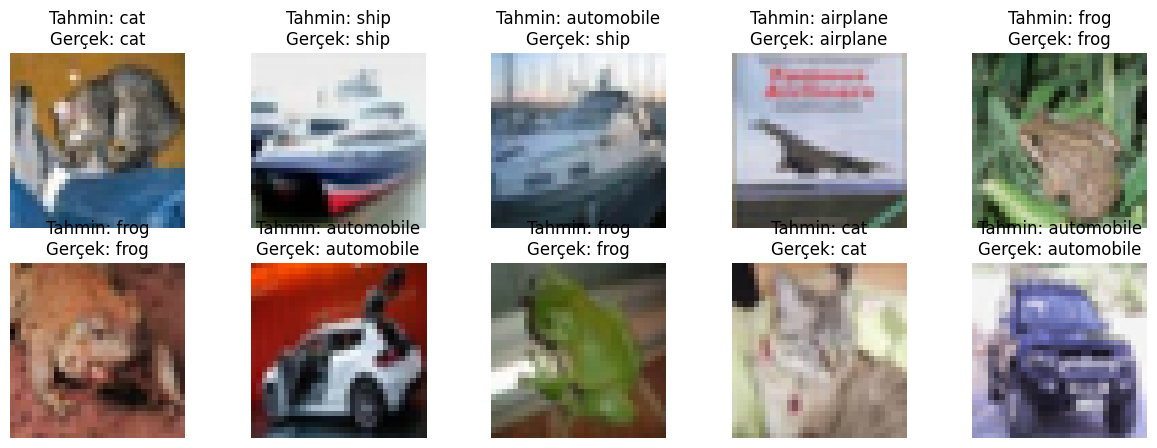

Model kaydedildi: /kaggle/working/cifar10_cnn_hypertuned_model.h5


In [13]:
# 12. Örnek Tahmin Görselleştirme
plt.figure(figsize=(15, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])
    plt.title(f"Tahmin: {class_names[y_pred_classes[i]]}\nGerçek: {class_names[y_test_classes[i]]}")
    plt.axis('off')
plt.savefig('/kaggle/working/sample_predictions.png')
plt.show()

# 13. Modeli Kaydetme
model.save('/kaggle/working/cifar10_cnn_hcifar10_cnn_hypertuned_model.h5

￼content_copy
￼more_vert
ypertuned_model.h5')
print("Model kaydedildi: /kaggle/working/cifar10_cnn_hypertuned_model.h5")